In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier

In [2]:
data = pd.read_csv('fruits_dataset.data')
data.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [3]:
data.isnull().sum()

fruit_label      0
fruit_name       0
fruit_subtype    0
mass             0
width            0
height           0
color_score      0
dtype: int64

In [4]:
data.value_counts("fruit_name")

fruit_name
apple       19
orange      19
lemon       16
mandarin     5
Name: count, dtype: int64

In [23]:
features = data.iloc[:, 3:7]
label = data.iloc[:, 1]


X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.2)


In [24]:
knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn.fit(X_train, y_train)
train_acc = knn.score(X_train, y_train)
print("The accuracy of KNN classifier on training data: {:.3f}".format(train_acc))

The accuracy of KNN classifier on training data: 1.000


In [25]:
knn_test_acc = knn.score(X_test, y_test)
print("The accuracy of KNN classifier on test data is: {:.3f}".format(knn_test_acc))

The accuracy of KNN classifier on test data is: 0.750


In [26]:
import pickle 
with open('knn_model', 'wb') as f:
    pickle.dump(knn,f)

In [27]:
with open('knn_model', 'rb') as f:
    model = pickle.load(f)

new_data = [80, 5.8, 4.5, 0.77]
X = np.array([new_data])
prediction = model.predict(X)

print("Prediction of species: {}".format(prediction))

Prediction of species: ['mandarin']


C:\Users\fayje_3xvy5tx\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Mass and Color Score')

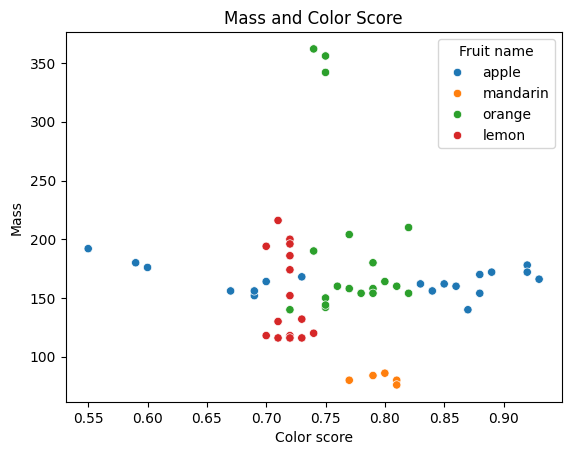

In [28]:
column_names = ["Fruit label", "Fruit name", "Fruit subtype", "Mass", "Width", "Height", "Color score"]
data.columns = column_names
data.head()
fig1 = sns.scatterplot(x = "Color score", y = "Mass", hue= "Fruit name", data=data )
fig1.set_title("Mass and Color Score")

Text(0.5, 1.0, 'Height and Width')

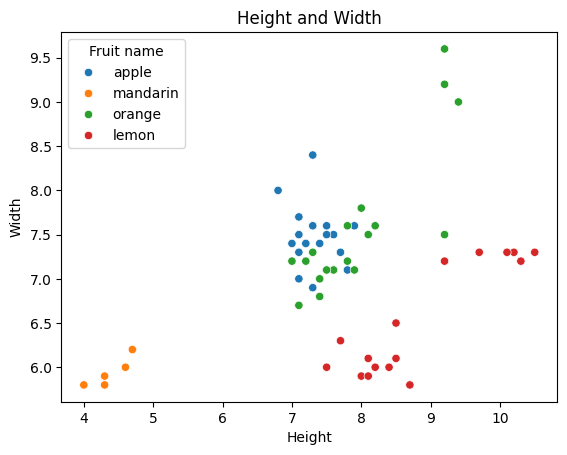

In [29]:
column_names = ["Fruit label", "Fruit name", "Fruit subtype", "Mass", "Width", "Height", "Color score"]
data.columns = column_names
data.head()
fig1 = sns.scatterplot(x = "Height", y = "Width", hue= "Fruit name", data=data )
fig1.set_title("Height and Width")

Text(0.5, 1.0, 'Confusion Matrix')

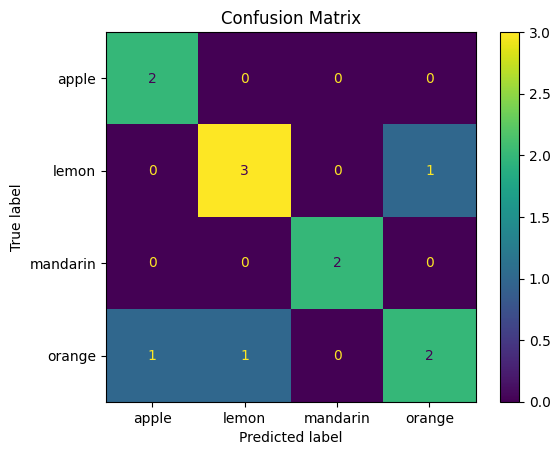

In [30]:
disp = ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
disp.ax_.set_title("Confusion Matrix")